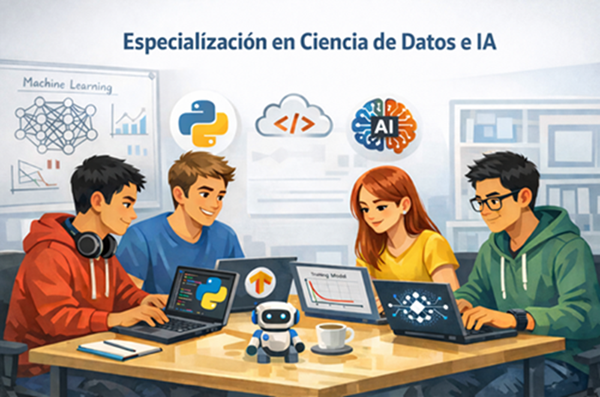

# MLOps - Parte I
## Análisis Exploratorio de Datos (EDA) del Secondary Mushroom Dataset

**Curso:** MLOps
**Profesora:** Maria Camila Durango Barrera  
**Dataset:** Secondary Mushroom Dataset  
**Fuente:** UCI Machine Learning Repository  
**Integrantes:** Daniela Gutierrez Garces, Carlos Andrés Morcillo Tapia, Andrés Felipe Lopez, Yessid Alejandro Restrepo Villa  
**Fecha:** 06 de abril de 2026

---


## 1. Introducción

Como parte de la primera entrega del curso de MLOps, este proyecto presenta un Análisis Exploratorio de Datos (EDA) del **Secondary Mushroom Dataset** del **UCI Machine Learning Repository**.

El dataset escogido es una dataset tabular de UCI para clasificación binaria que contiene alrededor de 61 mil observaciones de hongos simulados y 20 variables predictoras. Su objetivo es determinar si un hongo es comestible o venenoso, usando una combinación de variables numéricas y categóricas, lo que lo hace adecuado para análisis exploratorio, preprocesamiento y futuros modelos de machine learning.

En esta primera etapa, el enfoque no está en construir un modelo final de aprendizaje automático, sino en comprender la estructura, la calidad y los principales patrones de los datos. Este análisis servirá como base para etapas posteriores relacionadas con el preprocesamiento, el modelado, la orquestación y el despliegue dentro de un flujo de trabajo de MLOps.


## 2. Objetivo General

Realizar un Análisis Exploratorio de Datos (EDA) del **Secondary Mushroom Dataset** con el fin de comprender su estructura, identificar problemas de calidad de los datos, explorar variables numéricas y categóricas, analizar las relaciones entre las características y generar hallazgos que puedan orientar futuras etapas de aprendizaje automático y MLOps.


## 3. Objetivos Específicos

- Cargar e inspeccionar la estructura del dataset.
- Identificar valores faltantes, duplicados y posibles inconsistencias.
- Describir las variables numéricas y categóricas.
- Visualizar la distribución de la variable objetivo y de las características más relevantes.
- Analizar las correlaciones entre las variables numéricas.
- Extraer hallazgos clave que puedan apoyar futuras decisiones de preprocesamiento y modelado.


## 4. Descripción del Dataset

El **Secondary Mushroom Dataset** fue obtenido del **UCI Machine Learning Repository**.  
Contiene más de sesenta mil observaciones de hongos e incluye tanto variables **continuas** como **categóricas**. La variable objetivo indica si un hongo es **comestible** o **venenoso**.


## 5. Pregunta Orientadora

¿Qué patrones, distribuciones, problemas de calidad de datos y relaciones pueden identificarse en el **Secondary Mushroom Dataset** antes de avanzar hacia las etapas de preprocesamiento y aprendizaje automático?


## 6. Carga de Librerías y del Dataset

En esta sección, importamos las librerías necesarias de Python y cargamos el dataset en un DataFrame de pandas para realizar una inspección inicial.


In [15]:
# Pendiente de análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

## 7. Inspección Inicial de los Datos

Pendiente 


# Pendiente

In [14]:
# Pendiente de análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.


## 8. Evaluación de la Calidad de los Datos




Un EDA adecuado requiere evaluar la calidad del dataset antes de realizar un análisis más profundo.  
En esta sección, revisamos:
- valores faltantes,
- filas duplicadas,
- categorías inconsistentes,
- y posibles problemas en el ingreso de datos.

Este paso es importante porque los problemas de calidad de los datos pueden afectar futuras etapas de preprocesamiento y modelado.

In [ ]:
# Análisis exploratorio, como estadísticas descriptivas, distribución de clases, correlaciones

missing_count = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

display(missing_summary)

**Resumen de duplicados**

In [ ]:
# Análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

dup_count = df.duplicated().sum()
dup_percent = round((dup_count / len(df)) * 100, 2)

dup_summary = pd.DataFrame({
    "duplicate_rows": [dup_count],
    "duplicate_percent": [dup_percent]
})

display(dup_summary)

**Columnas numéricas y categóricas**

In [ ]:
# Análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns (incl. target):", categorical_cols)

**Comprobación de Target y columnas con cardinalidad muy alta o tokens extraños**

In [ ]:
print("Target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

rare_threshold = 0.001
cat_for_rarity = [c for c in categorical_cols if c != TARGET_COL]

rare_report = []

for col in cat_for_rarity:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        rare_report.append({
            "column": col,
            "n_rare_levels_under_0_1pct": int(rare.shape[0]),
            "pct_rows_in_rare_levels": round(float(rare.sum() * 100), 4)
        })

rare_report_df = pd.DataFrame(rare_report)

if not rare_report_df.empty:
    display(rare_report_df.sort_values("pct_rows_in_rare_levels", ascending=False))
else:
    print("No rare categorical levels found under 0.1%.")

## 9. Análisis Descriptivo

Para las variables numéricas, analizamos:

cantidad de datos,
media,
mediana,
desviación estándar,
valores mínimo y máximo,
y posibles valores atípicos.
Para las variables categóricas, analizamos:

las categorías más frecuentes,
el balance entre categorías,
y posibles etiquetas poco frecuentes. 


In [ ]:
# pendiprint("Target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

rare_threshold = 0.001
cat_for_rarity = [c for c in categorical_cols if c != TARGET_COL]

rare_report = []

for col in cat_for_rarity:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        rare_report.append({
            "column": col,
            "n_rare_levels_under_0_1pct": int(rare.shape[0]),
            "pct_rows_in_rare_levels": round(float(rare.sum() * 100), 4)
        })

rare_report_df = pd.DataFrame(rare_report)

if not rare_report_df.empty:
    display(rare_report_df.sort_values("pct_rows_in_rare_levels", ascending=False))
else:
    print("No rare categorical levels found under 0.1%.")
ente de análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.


In [ ]:
# ============================
# Resumen descriptivo de variables numéricas
# ============================
if len(numerical_cols) > 0:
    num_summary = df[numerical_cols].describe().T
    num_summary["median"] = df[numerical_cols].median()
    num_summary["missing_count"] = df[numerical_cols].isnull().sum()
    num_summary["missing_percent"] = (df[numerical_cols].isnull().mean() * 100).round(2)
    display(num_summary)
else:
    print("No numerical columns found.")

# ============================
# Medianas
# ============================
if len(numerical_cols) > 0:
    medians = df[numerical_cols].median()
    display(medians.to_frame("median"))
else:
    print("No numerical columns available for median calculation.")

# ============================
# Modas de variables categóricas + target
# ============================
cat_feats = [c for c in categorical_cols if c != TARGET_COL]
mode_cols = cat_feats + [TARGET_COL] if TARGET_COL in df.columns else cat_feats

if len(mode_cols) > 0:
    mode_dict = {}
    for col in mode_cols:
        col_mode = df[col].mode(dropna=True)
        mode_dict[col] = col_mode.iloc[0] if not col_mode.empty else np.nan

    modes = pd.DataFrame.from_dict(mode_dict, orient="index", columns=["mode"])
    display(modes)
else:
    print("No categorical columns found for mode calculation.")

# ============================
# Resumen de variables categóricas
# ============================
cat_summary_rows = []

for col in cat_feats:
    top_categories = df[col].value_counts(dropna=False).head(5).to_dict()
    cat_summary_rows.append({
        "column": col,
        "n_unique": df[col].nunique(dropna=False),
        "top_categories": str(top_categories)
    })

cat_summary_df = pd.DataFrame(cat_summary_rows)

if not cat_summary_df.empty:
    display(cat_summary_df)
else:
    print("No categorical feature summary available.")

# ============================
# Resumen de outliers usando IQR
# ============================
iqr_outlier_rows = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_percent = round((outlier_count / len(df)) * 100, 2)

    iqr_outlier_rows.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_percent": outlier_percent
    })

iqr_outliers = pd.DataFrame(iqr_outlier_rows)

if not iqr_outliers.empty:
    display(iqr_outliers)
else:
    print("No numerical columns available for IQR outlier analysis.")

## 10. Análisis de la Variable Objetivo

Dado que la futura tarea de aprendizaje automático será de clasificación binaria, es importante comprender la distribución de la clase objetivo.  
En esta sección, se explora si la variable objetivo está balanceada o desbalanceada y qué implicaciones puede tener esto para futuros procesos de modelado.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

vc = df[TARGET_COL].value_counts(dropna=False)
vp = df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100

target_balance = pd.DataFrame({
    "count": vc,
    "percent": vp.round(2)
})

display(target_balance)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COL, palette=["#4C72B0", "#DD8452"])
plt.title("Target distribution (edible vs poisonous)")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 11. Análisis Visual Exploratorio

Las visualizaciones ayudan a revelar patrones que son difíciles de identificar únicamente con tablas.

En esta sección, utilizamos:
- gráficos de barras para variables categóricas,
- histogramas para variables numéricas,
- diagramas de caja para detectar dispersión y valores atípicos,
- y gráficos comparativos agrupados por la clase objetivo.


In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Distribuciones de variables numéricas
# ============================
if len(numerical_cols) > 0:
    n = len(numerical_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# ============================
# Boxplots por variable objetivo
# ============================
if len(numerical_cols) > 0:
    n = len(numerical_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.boxplot(data=df, x=TARGET_COL, y=col, hue=TARGET_COL, dodge=False, ax=axes[i])
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()
        axes[i].set_title(f"{col} by {TARGET_COL}")
        axes[i].set_xlabel(TARGET_COL)
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns available for boxplots.")


# ============================
# Selección de variables categóricas a visualizar
# ============================
selected_cats = [
    "cap-shape",
    "cap-color",
    "habitat",
    "season",
    "gill-attachment",
]
selected_cats = [c for c in selected_cats if c in df.columns]


# ============================
# Top categorías por variable categórica
# ============================
if len(selected_cats) > 0:
    n = len(selected_cats)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(selected_cats):
        top_order = df[col].value_counts(dropna=False).head(10).index
        sns.countplot(data=df, x=col, order=top_order, hue=col, dodge=False, ax=axes[i])
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()
        axes[i].set_title(f"Top categories of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No selected categorical columns found in the dataset.")


# ============================
# Variables categóricas vs variable objetivo
# ============================
if len(selected_cats) > 0:
    n = len(selected_cats)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(selected_cats):
        top_order = df[col].value_counts(dropna=False).head(10).index
        sns.countplot(data=df, x=col, hue=TARGET_COL, order=top_order, ax=axes[i])
        axes[i].set_title(f"{col} vs {TARGET_COL}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No selected categorical columns found for target comparison.")

## 12. Análisis de Correlación

El análisis de correlación se centra en las variables numéricas del dataset.  
Esto nos ayuda a identificar si algunas características están relacionadas linealmente y si puede existir redundancia o dependencia entre ellas.

Se incluye un mapa de calor de correlación para facilitar la interpretación.

In [ ]:
# ============================
# Matriz de correlación
# ============================
corr = df[numerical_cols].corr(method="pearson", numeric_only=True)
display(corr)

# ============================
# Heatmap de correlación
# ============================
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Observamos una relación entre las variables 'stem-width' y 'cap-diameter' de acuerdo a su índice de correlación de 0.70

## 13. Principales Hallazgos

Con base en el análisis exploratorio, esta sección resume los hallazgos más importantes relacionados con:

la distribución de clases,
las variables relevantes,
los valores faltantes,
las categorías inusuales,
los valores atípicos,
y las posibles implicaciones para futuros flujos de trabajo de aprendizaje automático.


In [ ]:
# Pendiimport numpy as np

def _fmt_pct(x: float) -> str:
    return f"{x:.2f}%"

n_rows, n_cols = df.shape
n_miss = int(df.isna().sum().sum())
n_dup = int(df.duplicated().sum())

vc = df[TARGET_COL].value_counts(normalize=True) * 100
p_pct = float(vc.get("p", np.nan))
e_pct = float(vc.get("e", np.nan))

outlier_lines = []
if not iqr_outliers.empty:
    for _, r in iqr_outliers.iterrows():
        outlier_lines.append(
            f"  - {r['column']}: {int(r['outlier_count'])} rows ({r['outlier_percent']:.2f}%) beyond 1.5×IQR fences"
        )
else:
    outlier_lines.append("  - No numerical columns or no IQR summary computed.")

corr_high = []
if len(numerical_cols) >= 2:
    c = df[numerical_cols].corr(numeric_only=True)
    for i, a in enumerate(numerical_cols):
        for b in numerical_cols[i + 1:]:
            val = c.loc[a, b]
            if abs(val) >= 0.7:
                corr_high.append(f"{a} vs {b}: {val:.3f}")

print("EDA concise summary (Secondary Mushroom Dataset)")
print("=" * 60)
print(f"Rows: {n_rows:,} | Features (total columns): {n_cols}")
print(f"Missing values (cell-level): {n_miss:,}")
print(f"Fully duplicated rows: {n_dup:,}")
print(f"Numerical features: {numerical_cols}")

if pd.notna(p_pct) and pd.notna(e_pct):
    print(f"Target balance ({TARGET_COL}): p={_fmt_pct(p_pct)}, e={_fmt_pct(e_pct)}")
else:
    print(f"Target balance: {vc.to_dict()}")

print("IQR-based outliers (1.5×IQR):")
print("\n".join(outlier_lines))

if corr_high:
    print("Strong linear correlations (|r| ≥ 0.7):")
    for line in corr_high:
        print("  -", line)
else:
    print("Strong linear correlations (|r| ≥ 0.7): none detected among current numerical features.")

print("=" * 60)
print("Next steps (Part II): preprocessing pipeline, encoding, baseline model, tracking, evaluation.")
ente de análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.


## 14. Conclusiones y Próximos Pasos

Este EDA proporciona una comprensión inicial del **Secondary Mushroom Dataset** y establece la base para la siguiente fase del proyecto.

El trabajo futuro incluirá:
- pipelines de preprocesamiento,
- codificación de variables categóricas,
- escalado de variables numéricas si es necesario,
- entrenamiento y evaluación de modelos,
- seguimiento de experimentos,
- y consideraciones de despliegue como parte de un flujo de trabajo completo de MLOps.
